<a href="https://colab.research.google.com/github/vamsiram89/ML-Projects/blob/ML/Food_Delievery_Time_Prediction_by_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem statement:**


**Food delivery platforms face challenges in accurately estimating delivery time due to dynamic factors such as traffic conditions, weather, delivery distance, and varying order volumes. Inaccurate delivery time predictions can lead to poor customer experience and inefficient logistics planning.**

**This project aims to address this problem by developing a machine learning model that predicts food delivery time based on real-world features, enabling more accurate Estimated Time of Arrival (ETA) predictions.**

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

**Load Dataset**

In [ ]:
df = pd.read_csv("/content/sample_data/Food_Delivery_Times.csv")
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


**Data Cleaning**

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [ ]:
# missing values
df.dropna(inplace = True)
df.drop(['Order_ID'],axis =1,inplace = True)


In [ ]:
df.isnull().sum()

,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [ ]:
le = LabelEncoder()
df['Weather'] = le.fit_transform(df['Weather'])
df['Traffic_Level'] = le.fit_transform(df['Traffic_Level'])
df['Vehicle_Type'] = le.fit_transform(df['Vehicle_Type'])
df['Time_of_Day'] = le.fit_transform(df['Time_of_Day'])

**Feature and Target**

In [ ]:
y = df['Delivery_Time_min']
x = df.drop(['Delivery_Time_min'], axis=1)

In [ ]:
y

,Delivery_Time_min
0,43
1,84
2,59
3,37
4,68
...,...
995,54
996,71
997,81
998,55


In [ ]:
x

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,7.93,4,1,0,2,12,1.0
1,16.42,0,2,1,0,20,2.0
2,9.52,1,1,3,2,28,1.0
3,7.44,2,2,0,2,5,1.0
4,19.03,0,1,2,0,16,5.0
...,...,...,...,...,...,...,...
995,8.50,0,0,1,1,13,3.0
996,16.28,2,1,2,2,8,9.0
997,15.62,3,0,1,2,26,2.0
998,14.17,0,1,0,0,8,0.0


**Splitting the data**

In [ ]:
# Data Split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42)

**Scaling (CRITICAL for KNN)**

In [ ]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

**Train the Model**

In [ ]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(x_train, y_train)

KNeighborsRegressor()

**Prediction**

In [ ]:
y_pred = knn_model.predict(x_test)
y_pred

array([45.2, 28.2, 44. , 82.4, 63. , 78.8, 73. , 50.2, 66.4, 65.6, 70.8,
       40.6, 28.2, 68.4, 56.8, 55.8, 41.6, 87.2, 37. , 38. , 68.4, 56. ,
       62.6, 58.4, 57.2, 81. , 28.2, 43.6, 32. , 69.4, 85.4, 67.8, 38.4,
       53.4, 57.8, 27.4, 60.8, 37.8, 70.6, 39.4, 35.4, 36. , 74. , 53.6,
       60.2, 31.4, 66.8, 46. , 21. , 71.2, 31.6, 94.4, 42.2, 76.4, 53.6,
       48.8, 47.4, 42.8, 59.4, 70.4, 41. , 64.2, 44.4, 47.4, 57.8, 46. ,
       39.2, 41.4, 71.6, 73.4, 39.8, 78.4, 56.8, 44.4, 69.8, 64.6, 30.2,
       30.8, 53.8, 44. , 24.8, 42.8, 92.8, 24.4, 65.4, 70.8, 59. , 39.8,
       27.8, 58.4, 40. , 35.2, 50. , 43.4, 76.2, 26.8, 64. , 76.6, 75.6,
       40. , 43.6, 49.8, 51.2, 39.8, 56.6, 71.4, 25.6, 33.6, 99. , 48.6,
       50.4, 73.6, 44.8, 33.8, 69.8, 53.8, 50.8, 47. , 40.6, 82.6, 40.2,
       27.8, 65.8, 57.4, 43.4, 41.6, 46.4, 43.2, 40.8, 33.4, 65. , 51.2,
       31.2, 28.4, 54. , 62. , 44.4, 45.8, 40.8, 53.4, 49.4, 66.6, 81.8,
       62.2, 40.4, 57.2, 51.6, 43.6, 82.2, 72.4, 31

**Evaluation**

In [ ]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

RMSE: 10.7250801690602
R2: 0.7185669929559194


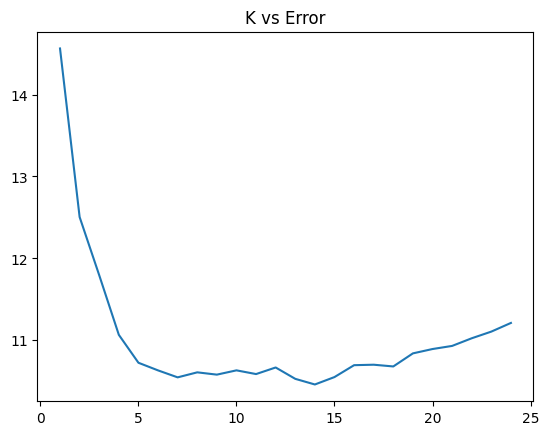

In [ ]:
# Find best K
errors = []

for k in range(1, 25):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    errors.append(np.sqrt(mean_squared_error(y_test, pred)))

plt.plot(range(1,25), errors)
plt.title("K vs Error")
plt.show()

**Hyperparameter tuning (finding best k)**

In [ ]:


rmse_list = []
k_values = range(1, 21)

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_list.append(rmse)

# 🔹 Get Best K
best_k = k_values[np.argmin(rmse_list)]

print("Best K value:", best_k)

# 🔹 Train Final Model with Best K
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(x_train, y_train)

y_pred_final = final_model.predict(x_test)

# 🔹 Final Results
print("Improved RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_final)))
print("Improved R2:", r2_score(y_test, y_pred_final))

Best K value: 14
Improved RMSE: 10.459777847141549
Improved R2: 0.7323181912674779
